Model Accuracy: 97.50%

Confusion Matrix:
[[ 9  0]
 [ 1 30]]


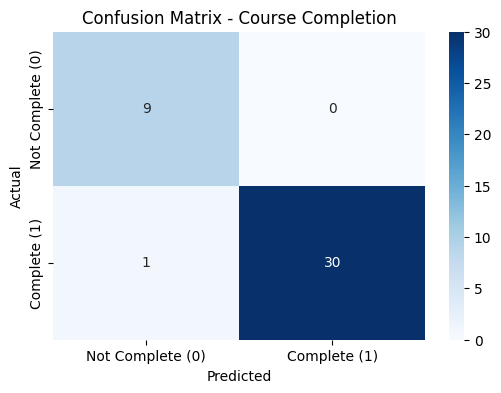


5 Predicted Examples:
     watched_lectures  completed_assignments  quiz_score  weekly_study_time        Actual     Predicted
95                 10                      6        96.5                7.7      Complete      Complete
15                 21                      8        74.7               12.1      Complete      Complete
30                 12                      8        45.1               19.7      Complete      Complete
158                12                      4        93.3               15.2      Complete      Complete
128                 1                      1        65.7                4.3  Not Complete  Not Complete


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
n = 200

watched_lectures = np.random.randint(1, 30, n)
completed_assignments = np.random.randint(0, 10, n)
quiz_score = np.random.uniform(40, 100, n)
weekly_study_time = np.random.uniform(1, 20, n)


score_index = (watched_lectures * 0.1) + (completed_assignments * 0.3) + (quiz_score * 0.05) + (weekly_study_time * 0.2)
completed = (score_index > 7.0).astype(int)

df = pd.DataFrame({
    'watched_lectures': watched_lectures,
    'completed_assignments': completed_assignments,
    'quiz_score': np.round(quiz_score, 1),
    'weekly_study_time': np.round(weekly_study_time, 1),
    'completed': completed
})


X = df[['watched_lectures', 'completed_assignments', 'quiz_score', 'weekly_study_time']]
y = df['completed']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Complete (0)', 'Complete (1)'],
            yticklabels=['Not Complete (0)', 'Complete (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Course Completion')
plt.show()

sample = X_test.head(5).copy()
sample['Actual'] = y_test.head(5).map({1: 'Complete', 0: 'Not Complete'})
sample['Predicted'] = pd.Series(y_pred[:5], index=sample.index).map({1: 'Complete', 0: 'Not Complete'})

print("\n5 Predicted Examples:")
print(sample.to_string())